In [12]:
from pathlib import Path

import pandas as pd
from tqdm import tqdm

from utils import train_models_for_target

# Configuration

In [13]:
DATA_DIR = Path("output")
CSV_PATTERN = "dataset_winsize*.csv"

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

TARGETS = {
    "label_time_to_event_seconds": "regression",
    "label_from_zone": "classification",
    "label_to_zone": "classification",
}

DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]

SUMMARY_FILENAME = "all_metrics_summary.csv"

MODEL_LABELS = {"tree": "Tree", "rf": "Random Forest"}

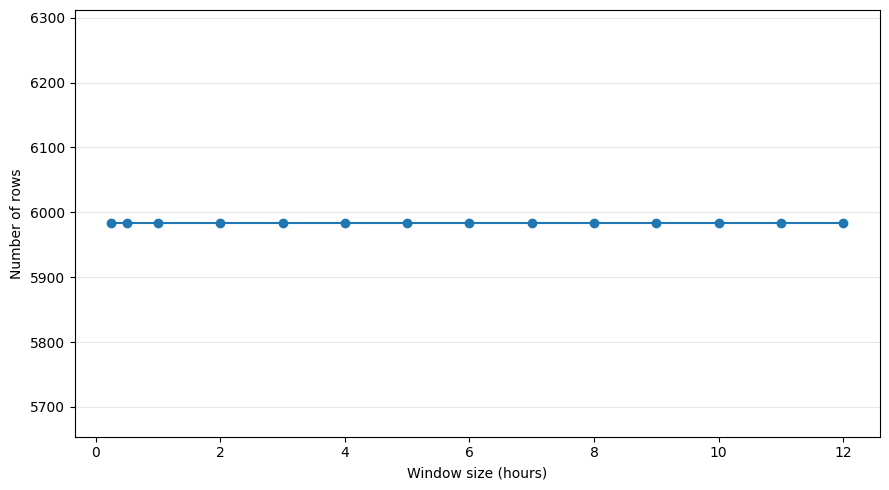

,dataset,winsize,winsize_hours,num_rows
0,dataset_winsize0.25h,0.25,0.25,5983
1,dataset_winsize0.5h,0.5,0.50,5983
2,dataset_winsize1h,1,1.00,5983
3,dataset_winsize2h,2,2.00,5983
4,dataset_winsize3h,3,3.00,5983
5,dataset_winsize4h,4,4.00,5983
6,dataset_winsize5h,5,5.00,5983
7,dataset_winsize6h,6,6.00,5983
8,dataset_winsize7h,7,7.00,5983
9,dataset_winsize8h,8,8.00,5983


In [14]:
import matplotlib.pyplot as plt

row_counts = []

for csv_path in sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h")),
):
    df = pd.read_csv(csv_path)
    winsize = csv_path.stem.split("winsize", 1)[1].removesuffix("h")
    row_counts.append(
        {
            "dataset": csv_path.stem,
            "winsize": winsize,
            "winsize_hours": float(winsize),
            "num_rows": len(df),
        }
    )

row_counts_df = pd.DataFrame(row_counts).sort_values("winsize_hours")

ax = row_counts_df.plot(
    x="winsize_hours",
    y="num_rows",
    kind="line",
    marker="o",
    figsize=(9, 5),
    legend=False,
)
ax.set_xlabel("Window size (hours)")
ax.set_ylabel("Number of rows")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

row_counts_df

In [ ]:
############
# RUN ONCE #
############
# Main loop over datasets (takes abut 30 minutes)

all_results = []

csv_files = sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h")),
)

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No files found matching {CSV_PATTERN} in {DATA_DIR.resolve()}"
    )

for csv_path in tqdm(csv_files):
    dataset_name = csv_path.stem
    print(f"\nReading {csv_path}")

    df = pd.read_csv(csv_path)

    for target_col, task_type in TARGETS.items():

        metrics_df = train_models_for_target(
            df=df,
            dataset_name=dataset_name,
            target_col=target_col,
            task_type=task_type,
            output_dir=OUTPUT_DIR,
            random_state=RANDOM_STATE,
            drop_columns=DROP_COLUMNS,
        )

        all_results.append(metrics_df)

final_results = pd.concat(all_results, ignore_index=True)
final_results.to_csv(OUTPUT_DIR / "all_metrics_summary.csv", index=False)

print("\nFinal summary:")
print(final_results)

  0%|          | 0/14 [00:00<?, ?it/s]


Reading output/dataset_winsize0.25h.csv

Dataset: dataset_winsize0.25h
Target: label_time_to_event_seconds
Task: regression

Training tree...
{'mae': 5325.690109009958, 'median_absolute_error': 737.8834498834499, 'mse': 132982924.74045248, 'rmse': np.float64(11531.822264518842), 'r2': 0.4488599062614649}

Top built-in feature importances for tree:
                    feature  importance
15  num_events_last_120_min    0.924697
14   num_events_last_60_min    0.016487
16         node_degree_mean    0.015489
19          node_degree_max    0.011290
18          node_degree_min    0.007456
11         num_unique_buses    0.006859
4           num_132kv_lines    0.003854
2            num_69kv_lines    0.003825
3           num_115kv_lines    0.003281
13   num_events_last_30_min    0.003159

Top permutation importances for tree:
                    feature  importance_mean  importance_std
15  num_events_last_120_min      6672.021453      256.555753
3           num_115kv_lines       227.832093    

  7%|▋         | 1/14 [02:10<28:12, 130.19s/it]


Top SHAP importances for rf:
                    feature  mean_abs_shap
16         node_degree_mean       0.005929
3           num_115kv_lines       0.005601
17          node_degree_std       0.005296
4           num_132kv_lines       0.005120
15  num_events_last_120_min       0.005054
19          node_degree_max       0.005024
18          node_degree_min       0.004129
12   num_events_last_15_min       0.003633
14   num_events_last_60_min       0.003487
13   num_events_last_30_min       0.003249

Reading output/dataset_winsize0.5h.csv

Dataset: dataset_winsize0.5h
Target: label_time_to_event_seconds
Task: regression

Training tree...
{'mae': 5423.761611368275, 'median_absolute_error': 746.0495049504952, 'mse': 136206062.54240373, 'rmse': np.float64(11670.73530427298), 'r2': 0.4355017967615672}

Top built-in feature importances for tree:
                    feature  importance
15  num_events_last_120_min    0.918771
18          node_degree_min    0.016945
14   num_events_last_60_min  

 14%|█▍        | 2/14 [04:30<27:15, 136.28s/it]

...


Top permutation importances for rf:
                    feature  importance_mean  importance_std
15  num_events_last_120_min      6671.410033      242.819431
14   num_events_last_60_min       187.317336        5.174705
17          node_degree_std        82.989698       50.015052
3           num_115kv_lines        75.399436       47.372065
11         num_unique_buses        74.684305       72.221574
13   num_events_last_30_min        40.303836        1.028534
5           num_220kv_lines        17.105365       20.328398
10         num_auto_outages        16.087524       24.071194
18          node_degree_min        13.640072       14.427343
12   num_events_last_15_min         9.159395        0.352465

Top SHAP importances for rf:
                    feature  mean_abs_shap
15  num_events_last_120_min    9966.136387
14   num_events_last_60_min     972.707043
4           num_132kv_lines     483.465266
16         node_degree_mean     475.354414
3           num_115kv_lines     416.180525
17  

 93%|█████████▎| 13/14 [36:19<03:01, 181.54s/it]


Top SHAP importances for rf:
                    feature  mean_abs_shap
16         node_degree_mean       0.004421
3           num_115kv_lines       0.004400
11         num_unique_buses       0.003947
15  num_events_last_120_min       0.003944
17          node_degree_std       0.003749
9       num_planned_outages       0.003212
19          node_degree_max       0.002841
14   num_events_last_60_min       0.002804
0                num_events       0.002655
1          num_unique_ptids       0.002619

Reading output/dataset_winsize12h.csv

Dataset: dataset_winsize12h
Target: label_time_to_event_seconds
Task: regression

Training tree...
{'mae': 5366.159001444038, 'median_absolute_error': 743.2539267015709, 'mse': 137958211.40909934, 'rmse': np.float64(11745.561349254422), 'r2': 0.42824011641787463}

Top built-in feature importances for tree:
                    feature  importance
15  num_events_last_120_min    0.867440
16         node_degree_mean    0.038878
19          node_degree_max  

100%|██████████| 14/14 [39:27<00:00, 169.07s/it]


Top SHAP importances for rf:
                    feature  mean_abs_shap
16         node_degree_mean       0.004438
3           num_115kv_lines       0.004279
17          node_degree_std       0.004002
15  num_events_last_120_min       0.003989
11         num_unique_buses       0.003645
9       num_planned_outages       0.003001
14   num_events_last_60_min       0.002856
19          node_degree_max       0.002688
1          num_unique_ptids       0.002553
0                num_events       0.002527

Final summary:
            mae  median_absolute_error           mse          rmse        r2  \
0   5325.690109             737.883450  1.329829e+08  11531.822265  0.448860   
1   5449.452976             707.305247  1.377103e+08  11735.004369  0.429267   
2           NaN                    NaN           NaN           NaN       NaN   
3           NaN                    NaN           NaN           NaN       NaN   
4           NaN                    NaN           NaN           NaN       NaN   
.

In [15]:
metrics_df = pd.read_csv(OUTPUT_DIR / SUMMARY_FILENAME)
metrics_df.head()

,mae,median_absolute_error,mse,rmse,r2,dataset,target,task,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,5325.690109,737.883450,1.329829e+08,11531.822265,0.448860,dataset_winsize0.25h,label_time_to_event_seconds,regression,tree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5449.452976,707.305247,1.377103e+08,11735.004369,0.429267,dataset_winsize0.25h,label_time_to_event_seconds,regression,rf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,dataset_winsize0.25h,label_from_zone,classification,tree,0.088555,0.050547,0.052361,0.050547,0.039069,0.127990,0.088555,0.078493
3,NaN,NaN,NaN,NaN,NaN,dataset_winsize0.25h,label_from_zone,classification,rf,0.126149,0.091826,0.099558,0.091826,0.079820,0.239419,0.126149,0.149177
4,NaN,NaN,NaN,NaN,NaN,dataset_winsize0.25h,label_to_zone,classification,tree,0.079365,0.056022,0.051060,0.056022,0.030738,0.155275,0.079365,0.065928


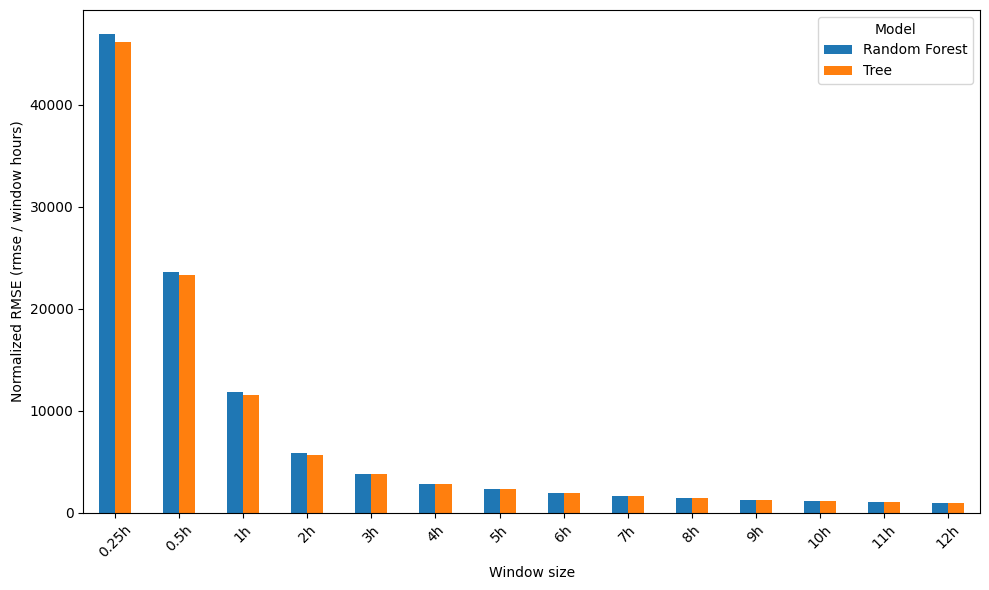

In [ ]:
import matplotlib.pyplot as plt

reg_df = metrics_df[
    (metrics_df["task"] == "regression") & (metrics_df["model"].isin(["tree", "rf"]))
].copy()

reg_df["winsize"] = reg_df["dataset"].str.extract(r"winsize(.+)$", expand=False)
reg_df["winsize_hours"] = (
    reg_df["winsize"].str.replace("h", "", regex=False).astype(float)
)
reg_df["rmse_norm"] = reg_df["rmse"] / reg_df["winsize_hours"]

reg_df = reg_df.sort_values("winsize_hours")
winsize_order = reg_df.drop_duplicates("winsize")["winsize"]

pivot = (
    reg_df.pivot(
        index="winsize",
        columns="model",
        values="rmse_norm",
    )
    .reindex(winsize_order)
    .rename(columns=MODEL_LABELS)
)

ax = pivot.plot(kind="bar", figsize=(10, 6))
ax.set_xlabel("Window size")
ax.set_ylabel("Normalized RMSE (rmse / window hours)")
# ax.set_title("Regression RMSE normalized by window size for tree vs rf")
ax.legend(title="Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DATA_DIR / "regression_rmse_norm_bar.pdf", dpi=300, bbox_inches="tight")
plt.show()

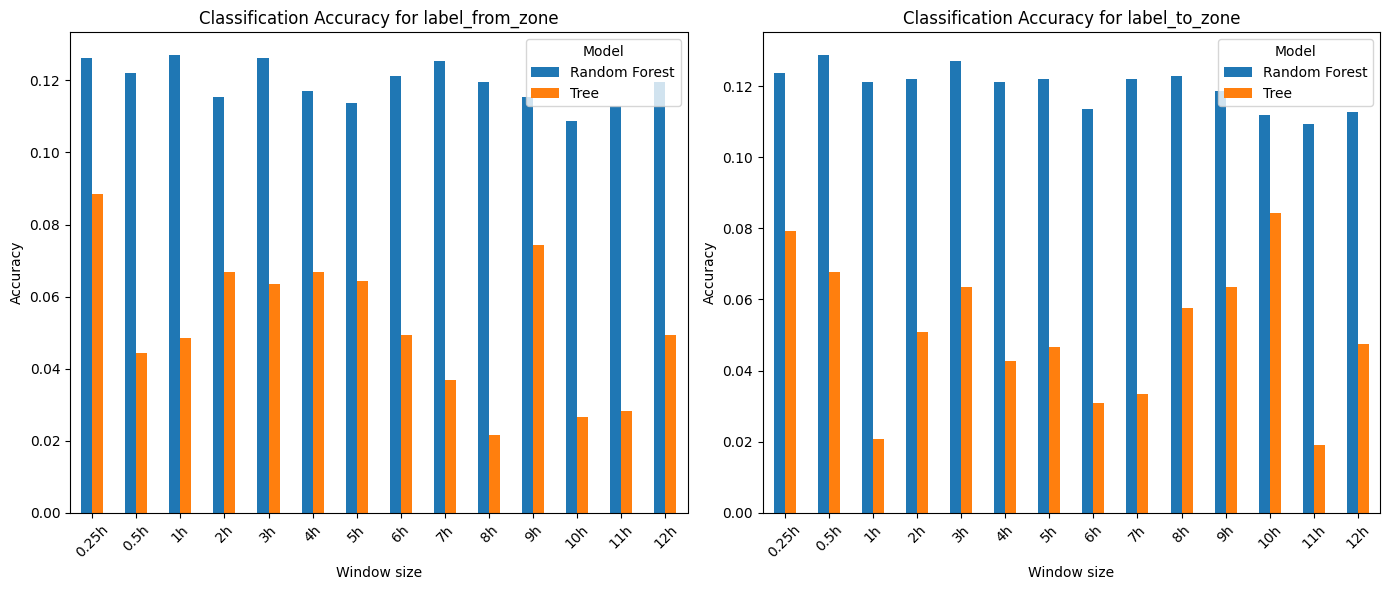

In [ ]:
class_df = metrics_df[
    (metrics_df["task"] == "classification")
    & (metrics_df["target"].isin(["label_from_zone", "label_to_zone"]))
    & (metrics_df["model"].isin(["tree", "rf"]))
].copy()

class_df["winsize"] = class_df["dataset"].str.extract(r"winsize(.+)$", expand=False)
class_df["winsize_hours"] = (
    class_df["winsize"].str.replace("h", "", regex=False).astype(float)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, target in enumerate(["label_from_zone", "label_to_zone"]):
    target_data = class_df[class_df["target"] == target].sort_values("winsize_hours")
    winsize_order = target_data.drop_duplicates("winsize")["winsize"]
    pivot = (
        target_data.pivot(index="winsize", columns="model", values="accuracy")
        .reindex(winsize_order)
        .rename(columns=MODEL_LABELS)
    )

    ax = pivot.plot(kind="bar", ax=axes[idx])
    ax.set_xlabel("Window size")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Classification Accuracy for {target}")
    ax.legend(title="Model")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [18]:
# train a classification model for time intervals
%run train_time_interval_classification.py

/home/aj/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aj/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aj/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aj/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util

             dataset  n_train  n_test  accuracy  balanced_accuracy  interval_weighted_accuracy  balanced_interval_weighted_accuracy  n_[0,1)  n_[1,2)  n_[2,4)  n_[4,8)  n_[8,inf)  accuracy_[0,1)  accuracy_[1,2)  accuracy_[2,4)  accuracy_[4,8)  accuracy_[8,inf)
dataset_winsize0.25h     4786    1197  0.736007           0.605919                    0.912698                             0.866957      538      183      181      179        116             1.0             1.0        0.342541        0.290503          0.396552
 dataset_winsize0.5h     4786    1197  0.741855           0.611264                    0.913534                             0.867309      538      183      181      179        116             1.0             1.0        0.364641        0.329609          0.362069
  dataset_winsize10h     4786    1197  0.755221           0.624039                    0.920844                             0.874823      538      183      181      179        116             1.0             1.0       

In [20]:
interval_metrics_path = OUTPUT_DIR / "time_interval_rf" / "all_interval_metrics.csv"
interval_df = pd.read_csv(interval_metrics_path)

interval_df["winsize"] = interval_df["dataset"].str.extract(
    r"winsize(.+)$", expand=False
)
interval_df["winsize_hours"] = (
    interval_df["winsize"].str.replace("h", "", regex=False).astype(float)
)
interval_df = interval_df.sort_values("winsize_hours")

metric_cols = [
    "accuracy",
    "balanced_accuracy",
    "interval_weighted_accuracy",
    "balanced_interval_weighted_accuracy",
]
class_accuracy_cols = [c for c in interval_df.columns if c.startswith("accuracy_[")]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

interval_df.plot(
    x="winsize",
    y=metric_cols,
    marker="o",
    ax=axes[0],
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].legend(title="Metric", loc="lower left")
axes[0].grid(axis="y", alpha=0.3)

class_accuracy = interval_df.set_index("winsize")[class_accuracy_cols]
class_accuracy.columns = [c.removeprefix("accuracy_") for c in class_accuracy.columns]
class_accuracy.plot(kind="bar", ax=axes[1])
axes[1].set_xlabel("Window size")
axes[1].set_ylabel("Per-class accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend(title="True interval", loc="lower left")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/aj/phd/nyiso-data/src/model_outputs/time_interval_rf/time_interval_rf/all_interval_metrics.csv'